In [47]:
import pandas as pd

In [48]:
df=pd.read_csv("expectation_decider_dataset.csv")

In [49]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,5,51,No,66,Fail
1,9,58,Yes,46,Fail
2,20,77,Yes,38,Pass
3,4,63,Yes,38,Fail
4,19,62,No,63,Pass


## Understanding the basics

### What is Probability?
#### Probability gives us the chance that a particular event will happen.
#### It measures how likely or unlikely an event is to occur.

### Key Probability Terminology
#### 1. Experiment
#### 2. Outcome
#### 3. Sample Space
#### 4. Event

### Probability Event Examples from Dataset

#### 1. Probability that a student studies more than 10 hours and fails

In [17]:
a = len(df[(df["study_hours"] > 10) & (df["final_exam_pass"] == "Fail")])

b = len(df)

p = a / b

print("Probability:", p)

Probability: 0.025


#### 2. Probability of failing the exam

In [18]:
a = len(df[df["final_exam_pass"] == "Fail"])

b = len(df)

p = a / b

print("Probability:", p)

Probability: 0.265


#### 3. Probability of passing the exam

In [19]:
a = len(df[df["final_exam_pass"] == "Pass"])

b = len(df)

p = a / b

print("Probability:", p)

Probability: 0.735


## Types of Events

### empirical probability

In [35]:
# Empirical probability is calculated using real observed data or experiments.
# It is based on actual outcomes collected from the dataset.
# Taking a random sample of 100 students
sample = df.sample(100, random_state=42)

# Calculating probability of passing
a = len(sample[sample["final_exam_pass"] == "Pass"])

b = len(sample)

p = a / b

print("Empirical Probability of Passing:", p)

Empirical Probability of Passing: 0.76


### theoretical probability

In [36]:
# Theoretical probability is calculated using mathematical formulas or complete known data.
# It represents the expected probability of an event.
# Calculating probability of passing using full dataset
a = len(df[df["final_exam_pass"] == "Pass"])

b = len(df)

p = a / b

print("Theoretical Probability of Passing:", p)

Theoretical Probability of Passing: 0.735


## Random Variable & Probability Distribution

In [43]:
# random variable is a varable that store event value in numbr formet
from scipy.stats import binom
import pandas as pd

# Number of selected students
n = 3

# Probability of passing
total_pass = len(df[df["final_exam_pass"] == "Pass"])
total_students = len(df)

p = total_pass / total_students

# Possible values of X
x_values = [0, 1, 2, 3]

# Calculate probabilities
probabilities = []

for x in x_values:
    prob = binom.pmf(x, n, p)
    probabilities.append(prob)

# Create probability distribution table
distribution_table = pd.DataFrame({
    "X (Students Passing)": x_values,
    "P(X=x)": probabilities
})

print(distribution_table)
#  mean of Random Variable 
mean = sum(distribution_table["X (Students Passing)"]*distribution_table["P(X=x)"])
print("mean:",mean)
variance = n*p*(1-p)
print("Variance:",variance)

   X (Students Passing)    P(X=x)
0                     0  0.018610
1                     1  0.154846
2                     2  0.429479
3                     3  0.397065
mean: 2.205
Variance: 0.5843250000000001


## Venn Diagram in Probability

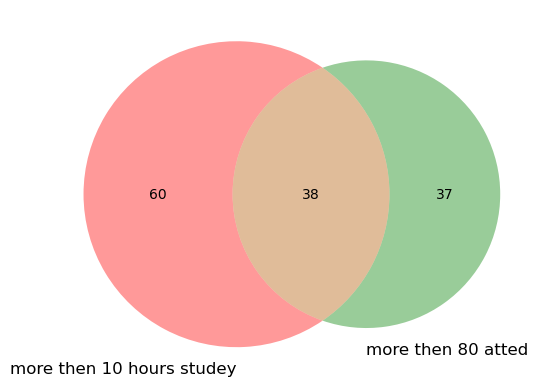

In [64]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
# student studey more then 3 hours
ta=len(df[df["study_hours"]>10])
#   student atted more then 80%
tb=len(df[df["attendance"]>80])
# student studey more then 10 hours and atted more then 80%
c=len(df[(df["study_hours"]>10) & (df["attendance"]>80)])

# more hen 10 hour only
a=ta-c
# more then 80 only 
b=tb-c
#  venn 
venn2(
    subsets=(a,b,c),
    set_labels=("more then 10 hours studey","more then 80 atted")
)
plt.show()

## Contingency table & Probability Calculation

In [85]:
# Contingency Table
Contingency_table = pd.crosstab(df["group_discussion"],df["final_exam_pass"],margins=True)
Contingency_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,36,71,107
Yes,17,76,93
All,53,147,200


In [88]:
# Contingency probability
Contingency_probability = pd.crosstab(df["group_discussion"],df["final_exam_pass"],margins=True,normalize="all")
Contingency_probability

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.180,0.355,0.535
Yes,0.085,0.380,0.465
All,0.265,0.735,1.000


In [89]:
#  joint oribability
#  participates in group discussion and passes exam
p=len(df[(df["group_discussion"]=="Yes") & (df["final_exam_pass"]=="Pass")])/ len(df)
print("Probability:",p)

Probability: 0.38


In [90]:
# Marginal Probability
#  passes exam
p=len(df[df["final_exam_pass"]=="Pass"])/len(df)
print("Probability:",p)

Probability: 0.735


## Understanding Relationships

####  what is the intuition behind Conditional proballity
##### - It tells us how the chance of one event changes because another event already occirred
##### - How the probability changes when we already know some information
- EX
- Without any information:
- Chance of rain = 40%
- But if you see dark clouds:
- Chance of rain becomes 80%

In [99]:
# Probability of discussions
a=len(df[df["group_discussion"]=="Yes"])/len(df)
print("probability of discussions:",a)
#  Probability of pass
b=len(df[df["final_exam_pass"]=="Pass"])/len(df)
print("Probability of passes:",b)
# probability of both
c=len(df[(df["group_discussion"]=="Yes") & (df["final_exam_pass"]=="Pass")])/len(df)
print("probability of both:",c)
#  chack independence
t1=a*b
if c== t1:
    print("both evnnt is independen")
else:
    print("Event is depaenden")

#  jutigy
#  P(A∩B)=P(A)P(B)
#  thids is formula of independence events
#  is c and t12 is same event is indepandence
#  event is not mutually becuase that event posibale in same time

probability of discussions: 0.465
Probability of passes: 0.735
probability of both: 0.38
Event is depaenden


## Bayes Theorem Application

In [105]:
# probability of high attendance given student passed
p_h_given_p=0.7
#  probability of high attendance given student failed
p_h_given_f=0.4
#  probability of high attendance
p_h=0.6
#  find = probability of student passed givend high attendance
# p(p|h)=?
# formula of bayes 
# P(A∣B)=P(B∣A)P(A)/p(B)

p=(p_h_given_p*(len(df[df["final_exam_pass"]=="Pass"])/len(df)))/p_h
print(p)

0.8574999999999999
